In [2]:
import sys
sys.path.append('../analysis')
from eeg_data import target_filenames
import numpy as np
from matplotlib import pyplot as plt
import os

import seaborn as sns

sns.set(font_scale=1.5)
sns.set_style('ticks')

plt.rcParams.update({
    'axes.titlesize': 'large',
    'axes.labelsize': 'large',
    'xtick.labelsize':'large',
    'ytick.labelsize':'large'
    })

In [3]:
eeg_dir = '/home/nmuller/projects/fmg_storage/osf_eeg_data/AutoReject'


sub_ids = {}
for sub in range(5, 36):

    filepath = f'/home/nmuller/projects/fmg_storage/OADS EEG Experiment/Subject_matrix/sub_{sub}_randomized_matrix_702.csv'
    with open(filepath, 'r') as f:
        lines = f.readlines()
    sub_ids[sub] = []

    for x in lines:
        if x.strip():
            for y in x.split(','):
                id = y.split('\\')[-1].split('.tiff')[0]
                if f"{id}.tiff" not in target_filenames:
                    sub_ids[sub].append(id)

In [4]:
same_images = np.zeros((len(sub_ids), len(sub_ids)), dtype=int)

In [5]:
ids_counter = {sub: {} for sub in sub_ids}

for sub in sub_ids:
    for image_id in sub_ids[sub]:
        ids_counter[sub][image_id] = ids_counter[sub].get(image_id, 0) + 1

for comp_sub in range(5, 36):
    for sub in range(5, 36):
        if sub == comp_sub:
            continue

        comb_train_ids = [x for x in ids_counter[comp_sub].keys() if ids_counter[comp_sub][x] == 5]
        comb_test_ids = [x for x in ids_counter[comp_sub].keys() if ids_counter[comp_sub][x] == 10]

        sub_train_ids = [x for x in ids_counter[sub].keys() if ids_counter[sub][x] == 5]
        sub_test_ids = [x for x in ids_counter[sub].keys() if ids_counter[sub][x] == 10]

        if sorted(set(comb_train_ids)) == sorted(set(sub_train_ids)):
            same_images[sub - 5, comp_sub - 5] += 1
        if sorted(set(comb_test_ids)) == sorted(set(sub_test_ids)):
            same_images[sub - 5, comp_sub - 5] += 2

In [6]:
figure_dir = '/home/nmuller/projects/fmg_storage/tux20_oads_eeg_paper_figures'

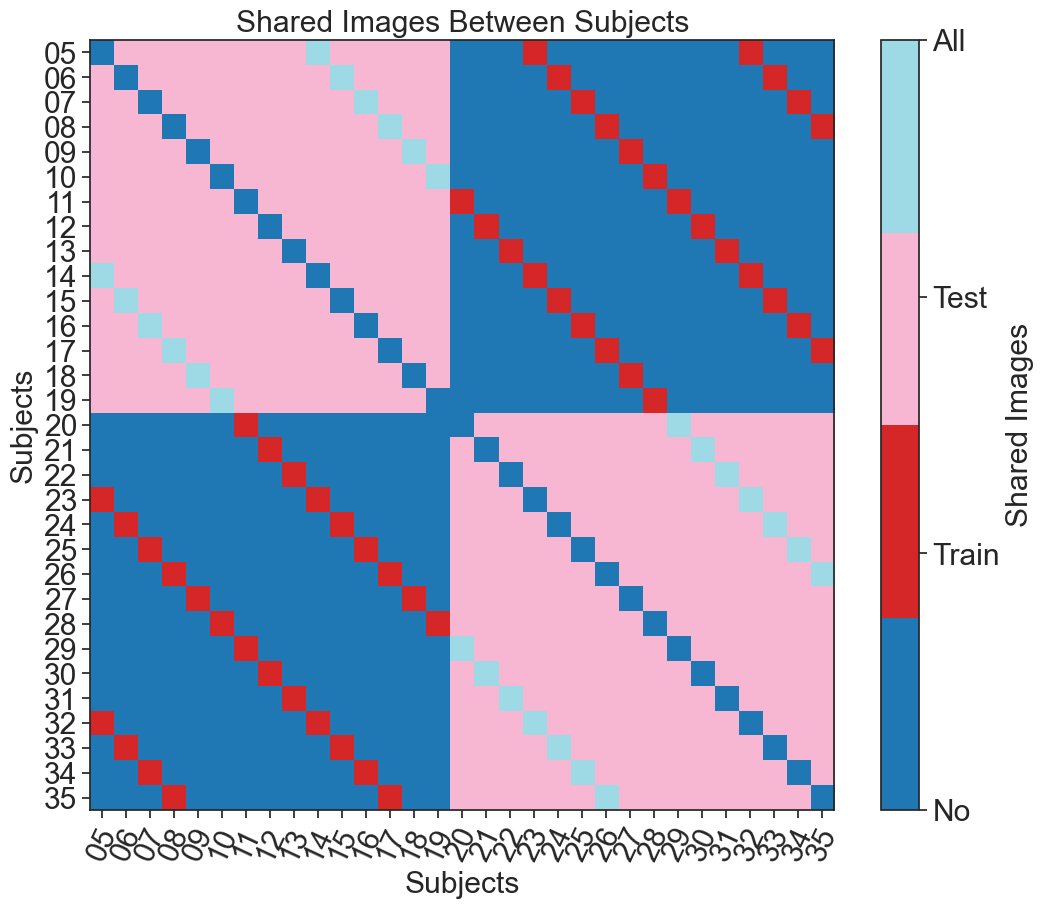

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
cmap = plt.get_cmap('tab20', 4)
im = ax.imshow(same_images, aspect='auto', cmap=cmap, interpolation='nearest')
cax = plt.colorbar(im, ax=ax)
cax.set_label('Shared Images') # , fontsize=20
cax.set_ticks(ticks=[0, 1, 2, 3], labels=['No', 'Train', 'Test', 'All']) # , fontsize=18
# cax.set_ticklabels(['No', 'Train', 'Test', 'All'])
ax.set_xlabel('Subjects') # , fontsize=20
ax.set_ylabel('Subjects') # , fontsize=20

ax.set_xticks(range(len(sub_ids)), [f'{str(i + 5).zfill(2)}' for i in range(len(sub_ids))], rotation=65) # , fontsize=18
ax.set_yticks(range(len(sub_ids)), [f'{str(i + 5).zfill(2)}' for i in range(len(sub_ids))]) # , fontsize=18
ax.set_title('Shared Images Between Subjects') # , fontsize=24

# plt.savefig('../figures/images_per_subject.pdf', bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(figure_dir, 'SUPPL_Fig-6_shared_images_between_subjects.pdf'), dpi=300, bbox_inches='tight')
plt.show()